In [ ]:
from google.colab import drive; drive.mount('/content/drive')
import os

BASE      = '/content/drive/MyDrive/Mental-Health'
TEXT_EMB  = os.path.join(BASE, 'outputs', 'text',   'text_embeddings.npz')
VOICE_EMB = os.path.join(BASE, 'outputs', 'voice',  'voice_embeddings.npz')
FACE_EMB  = os.path.join(BASE, 'outputs', 'facial', 'facial_embeddings.npz')

EXT_LABEL  = os.path.join(BASE, 'Extended-DAIC', 'labels')
DAIC_OLD   = os.path.join(BASE, 'DAIC')
DAIC_LABEL = DAIC_OLD
OUT        = os.path.join(BASE, 'outputs', 'fusion')
os.makedirs(OUT, exist_ok=True)

HAS_EXT_LABEL  = os.path.isdir(EXT_LABEL)
HAS_DAIC_LABEL = os.path.isdir(DAIC_LABEL)

for p, n in [(TEXT_EMB,'text'),(VOICE_EMB,'voice'),(FACE_EMB,'facial')]:
    print(f'{n}: {"✅" if os.path.exists(p) else "❌ MISSING — run that notebook first"}')

print(f'\nExtended-DAIC labels: {"✅" if HAS_EXT_LABEL  else "❌"}')
print(f'DAIC-WOZ labels     : {"✅" if HAS_DAIC_LABEL else "❌"}')
assert HAS_EXT_LABEL or HAS_DAIC_LABEL, 'No label directory found!'


Mounted at /content/drive
text: ✅
voice: ✅
facial: ✅

Extended-DAIC labels: ✅
DAIC-WOZ labels     : ✅


In [2]:
!pip install -q shap scikit-learn torch
import torch; print('GPU:', torch.cuda.is_available(),
                    torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')

GPU: False none


## Imports + Config

In [3]:
import os, json, random, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import shap, matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
BINARY_THR = 10
SEED       = 42
CLASS_NAMES= ['Not depressed', 'Depressed']
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('Device:', DEVICE)

Device: cpu


## Step 1 — Load Embeddings + Labels, Align by participant_id

In [ ]:
def load_emb(path):
    d = np.load(path)
    return d['embeddings'].astype(np.float32), d['ids'].astype(int)

text_emb,  text_ids  = load_emb(TEXT_EMB)
voice_emb, voice_ids = load_emb(VOICE_EMB)
face_emb,  face_ids  = load_emb(FACE_EMB)

print(f'Text   embeddings : {text_emb.shape}')
print(f'Voice  embeddings : {voice_emb.shape}')
print(f'Facial embeddings : {face_emb.shape}')

BINARY_THR = 10

def parse_label_df(df):
    df = df.copy()
    df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
    phq = next((c for c in df.columns if 'phq8' in c or ('phq' in c and 'score' in c)), None)
    if phq is None: phq = next((c for c in df.columns if 'phq' in c), None)
    pid = next((c for c in df.columns
                if 'participant' in c or c in ('id','pid','subject')), None)
    if phq is None or pid is None:
        raise ValueError(f'Cannot find PHQ/PID. Got: {list(df.columns)}')
    df['label'] = (df[phq].astype(float) >= BINARY_THR).astype(int)
    df = df.rename(columns={pid: 'participant_id', phq: 'phq_score'})
    return df[['participant_id','label']].dropna().astype({'participant_id': int})

all_label_dfs = []
if HAS_EXT_LABEL:
    for fname in ['train_split.csv','dev_split.csv','test_split.csv','Detailed_PHQ8_Labels.csv']:
        p = os.path.join(EXT_LABEL, fname)
        if not os.path.exists(p): continue
        try:
            df = parse_label_df(pd.read_csv(p))
            all_label_dfs.append(df)
            print(f'Extended-DAIC {fname:40s}: {len(df)} | dep={df.label.sum()}')
        except Exception as e:
            print(f'  Skipping {fname}: {e}')

if HAS_DAIC_LABEL:
    for fname in ['labels.csv',
                  'train_split_Depression_AVEC2017.csv',
                  'dev_split_Depression_AVEC2017.csv']:
        p = os.path.join(DAIC_LABEL, fname)
        if not os.path.exists(p): continue
        try:
            df = parse_label_df(pd.read_csv(p))
            all_label_dfs.append(df)
            print(f'DAIC-WOZ {fname:50s}: {len(df)} | dep={df.label.sum()}')
        except Exception as e:
            print(f'  Skipping {fname}: {e}')

assert all_label_dfs, 'No label files found in either dataset!'

ldf = (pd.concat(all_label_dfs)
         .drop_duplicates('participant_id')
         .reset_index(drop=True))

print(f'\n=== COMBINED LABELS ===')
print(f'Total unique participants : {len(ldf)}')
print(f'Depressed (PHQ>=10)      : {ldf.label.sum()}')
print(f'Not depressed            : {(ldf.label==0).sum()}')

label_lut = ldf.set_index('participant_id')['label'].to_dict()

t_lut = {pid: emb for pid, emb in zip(text_ids,  text_emb)}
v_lut = {pid: emb for pid, emb in zip(voice_ids, voice_emb)}
f_lut = {pid: emb for pid, emb in zip(face_ids,  face_emb)}

common = sorted(set(t_lut) & set(v_lut) & set(f_lut) & set(label_lut))
print(f'Aligned participants (all 3 modalities + label): {len(common)}')

tv_common = sorted(set(t_lut) & set(v_lut) & set(label_lut))
tf_common = sorted(set(t_lut) & set(f_lut) & set(label_lut))
print(f'Text+Voice only: {len(tv_common)} | Text+Facial only: {len(tf_common)}')

X_text  = np.array([t_lut[p] for p in common])
X_voice = np.array([v_lut[p] for p in common])
X_face  = np.array([f_lut[p] for p in common])
X_fused = np.hstack([X_text, X_voice, X_face])
y       = np.array([label_lut[p] for p in common])
pids    = np.array(common)

TEXT_DIM  = X_text.shape[1]
VOICE_DIM = X_voice.shape[1]
FACE_DIM  = X_face.shape[1]
FUSED_DIM = X_fused.shape[1]

print(f'\nFusion vector: {TEXT_DIM} + {VOICE_DIM} + {FACE_DIM} = {FUSED_DIM} dims')
print(f'Labels — dep: {y.sum()} | non-dep: {(y==0).sum()}')

Text   embeddings : (142, 1536)
Voice  embeddings : (142, 2)
Facial embeddings : (275, 132)
Extended-DAIC train_split.csv                         : 163 | dep=50
Extended-DAIC dev_split.csv                           : 56 | dep=15
Extended-DAIC test_split.csv                          : 56 | dep=21
Extended-DAIC Detailed_PHQ8_Labels.csv                : 219 | dep=0
DAIC-WOZ labels.csv                                        : 142 | dep=43

=== COMBINED LABELS ===
Total unique participants : 275
Depressed (PHQ>=10)      : 86
Not depressed            : 189
Aligned participants (all 3 modalities + label): 142
Text+Voice only: 142 | Text+Facial only: 142

Fusion vector: 1536 + 2 + 132 = 1670 dims
Labels — dep: 43 | non-dep: 99


## Step 2 — Split (Official Extended-DAIC splits + DAIC-WOZ → train)


In [ ]:
def load_pid_set(fname):
    p = os.path.join(EXT_LABEL, fname)
    if not os.path.exists(p): return set()
    df = pd.read_csv(p)
    df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
    pid_col = next((c for c in df.columns if 'participant' in c or c in ('id','pid')), None)
    return set(df[pid_col].astype(int)) if pid_col else set()

train_pids_off = load_pid_set('train_split.csv')
dev_pids_off   = load_pid_set('dev_split.csv')
test_pids_off  = load_pid_set('test_split.csv')

used_official_splits = False
if len(train_pids_off) and len(dev_pids_off) and len(test_pids_off):
    tr_mask = np.array([p in train_pids_off for p in pids])
    va_mask = np.array([p in dev_pids_off   for p in pids])
    te_mask = np.array([p in test_pids_off  for p in pids])

    tr_temp = np.where(tr_mask)[0]
    va_temp = np.where(va_mask)[0]
    te_temp = np.where(te_mask)[0]

    if len(te_temp) > 0:
        print('Using Extended-DAIC official splits')
        unassigned = ~(tr_mask | va_mask | te_mask)
        tr_mask |= unassigned
        tr = np.where(tr_mask)[0]
        va = np.where(va_mask)[0]
        te = np.where(te_mask)[0]
        used_official_splits = True
    else:
        print('Official splits resulted in an empty test set. Falling back to random stratified split.')

if not used_official_splits:
    print('Using random stratified split')
    all_idx = np.arange(len(y))
    tv_idx, te_idx = train_test_split(all_idx, test_size=0.15, stratify=y, random_state=SEED)
    tr_idx, va_idx = train_test_split(tv_idx, test_size=0.15/0.85, stratify=y[tv_idx], random_state=SEED)
    tr, va, te = tr_idx, va_idx, te_idx

def split(X): return X[tr], X[va], X[te]
Xf_tr,  Xf_va,  Xf_te  = split(X_fused)
Xt_tr,  Xt_va,  Xt_te  = split(X_text)
Xv_tr,  Xv_va,  Xv_te  = split(X_voice)
Xfa_tr, Xfa_va, Xfa_te = split(X_face)
y_tr,   y_va,   y_te   = y[tr], y[va], y[te]

print(f'Train:{len(tr)} Val:{len(va)} Test:{len(te)}')
print(f'Train dep: {y_tr.mean():.2f} | Val dep: {y_va.mean():.2f} | Test dep: {y_te.mean():.2f}')

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
CW = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
print(f'Class weights: {cw.round(3)}')

Official splits resulted in an empty test set. Falling back to random stratified split.
Using random stratified split
Train:98 Val:22 Test:22
Train dep: 0.30 | Val dep: 0.32 | Test dep: 0.32
Class weights: [0.71 1.69]


## Step 3 — Attention-Gated Fusion MLP

In [ ]:
class FusionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class ModalityAttentionFusion(nn.Module):
    """
    Multimodal fusion with learned attention gates per modality.
    Each modality is first projected, then gated, then concatenated.
    """
    def __init__(self, text_dim, voice_dim, face_dim, proj_dim=128):
        super().__init__()
        self.text_dim  = text_dim
        self.voice_dim = voice_dim
        self.face_dim  = face_dim
        self.text_proj  = nn.Sequential(nn.Linear(text_dim,  proj_dim), nn.LayerNorm(proj_dim), nn.GELU())
        self.voice_proj = nn.Sequential(nn.Linear(voice_dim, proj_dim), nn.LayerNorm(proj_dim), nn.GELU())
        self.face_proj  = nn.Sequential(nn.Linear(face_dim,  proj_dim), nn.LayerNorm(proj_dim), nn.GELU())

        self.attn_gate = nn.Sequential(
            nn.Linear(proj_dim * 3, 3),
            nn.Softmax(dim=-1)
        )

        self.fusion = nn.Sequential(
            nn.Linear(proj_dim * 3, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 256),          nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),          nn.GELU()
        )
        self.head = nn.Linear(128, 2)

    def _split(self, x):
        t = x[:, :self.text_dim]
        v = x[:, self.text_dim:self.text_dim + self.voice_dim]
        f = x[:, self.text_dim + self.voice_dim:]
        return t, v, f

    def forward(self, x):
        t, v, f   = self._split(x)
        pt = self.text_proj(t)
        pv = self.voice_proj(v)
        pf = self.face_proj(f)

        cat  = torch.cat([pt, pv, pf], dim=-1)
        gate = self.attn_gate(cat)

        fused = torch.cat([
            pt * gate[:,0:1],
            pv * gate[:,1:2],
            pf * gate[:,2:3],
        ], dim=-1)

        emb = self.fusion(fused)
        return self.head(emb), gate 

    def get_logits(self, x):
        logits, _ = self.forward(x)
        return logits

    def embed(self, x):
        """128-dim embedding for downstream tasks."""
        with torch.no_grad():
            t, v, f = self._split(x)
            pt = self.text_proj(t)
            pv = self.voice_proj(v)
            pf = self.face_proj(f)
            cat  = torch.cat([pt, pv, pf], dim=-1)
            gate = self.attn_gate(cat)
            fused = torch.cat([pt*gate[:,0:1], pv*gate[:,1:2], pf*gate[:,2:3]], dim=-1)
            return self.fusion(fused)


class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        n_cls = logits.size(-1)
        log_p = F.log_softmax(logits, dim=-1)
        smooth_t = torch.full_like(log_p, self.smoothing / (n_cls-1))
        smooth_t.scatter_(-1, targets.unsqueeze(-1), 1.0 - self.smoothing)
        loss = -(smooth_t * log_p).sum(-1)
        if self.weight is not None:
            loss = loss * self.weight[targets]
        return loss.mean()


def make_loader(X, y, batch=24, weighted=False):
    ds = FusionDataset(X, y)
    if weighted:
        counts = np.bincount(y, minlength=2)
        w = torch.tensor([1.0/(counts[l]+1e-9) for l in y], dtype=torch.float32)
        return DataLoader(ds, batch_size=batch, sampler=WeightedRandomSampler(w, len(w)))
    return DataLoader(ds, batch_size=batch, shuffle=False)


def best_threshold(y_true, y_prob, metric='macro'):
    thrs = np.arange(0.05, 0.96, 0.01)
    scores = [f1_score(y_true,(y_prob>=t).astype(int),average=metric,zero_division=0) for t in thrs]
    return float(thrs[np.argmax(scores)]), float(max(scores))


def train_fusion(X_tr, y_tr, X_va, y_va, X_te, y_te,
                 name='Fusion', epochs=80, lr=1e-4, use_attention=False):
    """
    Train either the attention-gated fusion model or a plain MLP (for unimodal baselines).
    """
    if use_attention:
        model = ModalityAttentionFusion(TEXT_DIM, VOICE_DIM, FACE_DIM).to(DEVICE)
        fwd = model.get_logits
    else:
        model = nn.Sequential(
            nn.Linear(X_tr.shape[1], 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 64),  nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 2)
        ).to(DEVICE)
        fwd = model

    crit      = LabelSmoothingCE(smoothing=0.1, weight=CW)
    opt       = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch       = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    tr_ld     = make_loader(X_tr, y_tr, weighted=True)
    va_ld     = make_loader(X_va, y_va)
    te_ld     = make_loader(X_te, y_te)
    best_path = os.path.join(OUT, f'{name.lower().replace(" ","_")}_v2.pt')
    best_f1   = -1.0

    for ep in range(epochs):
        model.train()
        for xb, yb in tr_ld:
            opt.zero_grad()
            crit(fwd(xb.to(DEVICE)), yb.to(DEVICE)).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval(); vp, vprob = [], []
        with torch.no_grad():
            for xb, _ in va_ld:
                logits = fwd(xb.to(DEVICE))
                vp.extend(logits.argmax(-1).cpu().numpy())
                vprob.extend(torch.softmax(logits,-1)[:,1].cpu().numpy())
        vf1 = f1_score(y_va, vp, average='weighted', zero_division=0)
        if vf1 > best_f1:
            best_f1 = vf1; torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model.eval(); tp, tprob_va, tprob_te = [], [], []

    with torch.no_grad():
        for xb, _ in va_ld:
            tprob_va.extend(torch.softmax(fwd(xb.to(DEVICE)),-1)[:,1].cpu().numpy())

    with torch.no_grad():
        for xb, _ in te_ld:
            logits = fwd(xb.to(DEVICE))
            tp.extend(logits.argmax(-1).cpu().numpy())
            tprob_te.extend(torch.softmax(logits,-1)[:,1].cpu().numpy())

    va_prob = np.array(tprob_va)
    te_prob = np.array(tprob_te)
    thr, _ = best_threshold(y_va, va_prob)
    y_pred  = (te_prob >= thr).astype(int)

    m = {
        'accuracy': float(accuracy_score(y_te, y_pred)),
        'f1':       float(f1_score(y_te, y_pred, average='weighted', zero_division=0)),
        'f1_macro': float(f1_score(y_te, y_pred, average='macro', zero_division=0)),
        'f1_pos':   float(f1_score(y_te, y_pred, pos_label=1, average='binary', zero_division=0)),
        'roc_auc':  float(roc_auc_score(y_te, te_prob)),
        'threshold': thr,
    }
    print(f'{name:<22} acc={m["accuracy"]:.4f}  F1-w={m["f1"]:.4f}  '
          f'F1-mac={m["f1_macro"]:.4f}  AUC={m["roc_auc"]:.4f}  thr={thr:.2f}')
    return model, y_pred, te_prob, va_prob, m, best_path

print('Training setup ready')

Training setup ready


## Step 4 — Train Unimodal Baselines + Attention-Gated Fusion

In [ ]:
print('Training all models...')
print(f'{"Model":<22} {"Acc":>7} {"F1-w":>7} {"F1-mac":>8} {"AUC":>7} {"Thr":>6}')
print('-'*65)
results = {}

_, tp_t, prob_t, vp_t, m_t, _ = train_fusion(
    Xt_tr, y_tr, Xt_va, y_va, Xt_te, y_te, 'Text only')
results['Text only'] = m_t

_, tp_v, prob_v, vp_v, m_v, _ = train_fusion(
    Xv_tr, y_tr, Xv_va, y_va, Xv_te, y_te, 'Voice only')
results['Voice only'] = m_v

_, tp_f, prob_f, vp_f, m_f, _ = train_fusion(
    Xfa_tr, y_tr, Xfa_va, y_va, Xfa_te, y_te, 'Facial only')
results['Facial only'] = m_f

fusion_model, tp_fus, prob_fus, vp_fus, m_fus, fusion_path = train_fusion(
    Xf_tr, y_tr, Xf_va, y_va, Xf_te, y_te,
    name='Attention Fusion', epochs=80, lr=1e-4, use_attention=True
)
results['Attention Fusion'] = m_fus

soft_va = 0.15*vp_t + 0.10*vp_v + 0.10*vp_f + 0.65*vp_fus
soft_te = 0.15*prob_t + 0.10*prob_v + 0.10*prob_f + 0.65*prob_fus
ens_thr, _ = best_threshold(y_va, soft_va)
ens_pred   = (soft_te >= ens_thr).astype(int)
results['SoftVote Ensemble'] = {
    'accuracy': float(accuracy_score(y_te, ens_pred)),
    'f1':       float(f1_score(y_te, ens_pred, average='weighted', zero_division=0)),
    'f1_macro': float(f1_score(y_te, ens_pred, average='macro', zero_division=0)),
    'f1_pos':   float(f1_score(y_te, ens_pred, pos_label=1, average='binary', zero_division=0)),
    'roc_auc':  float(roc_auc_score(y_te, soft_te)),
    'threshold': ens_thr,
}
m_ens = results['SoftVote Ensemble']
print(f'{"SoftVote Ensemble":<22} acc={m_ens["accuracy"]:.4f}  F1-w={m_ens["f1"]:.4f}  '
      f'F1-mac={m_ens["f1_macro"]:.4f}  AUC={m_ens["roc_auc"]:.4f}')

with open(os.path.join(OUT,'comparison_results_v2.json'),'w') as f:
    json.dump(results, f, indent=2)

Training all models...
Model                      Acc    F1-w   F1-mac     AUC    Thr
-----------------------------------------------------------------
Text only              acc=0.5455  F1-w=0.5568  F1-mac=0.5417  AUC=0.6190  thr=0.34
Voice only             acc=0.6818  F1-w=0.6162  F1-mac=0.5111  AUC=0.6381  thr=0.50
Facial only            acc=0.9091  F1-w=0.9091  F1-mac=0.8952  AUC=0.9238  thr=0.50
Attention Fusion       acc=0.8636  F1-w=0.8606  F1-mac=0.8362  AUC=0.8381  thr=0.50
SoftVote Ensemble      acc=0.8636  F1-w=0.8606  F1-mac=0.8362  AUC=0.8381


## Step 5 — 5-Fold Cross-Validation on Fusion

In [11]:
print('Running 5-fold CV on attention fusion model...')
kf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_tv  = np.vstack([Xf_tr, Xf_va])
y_tv  = np.concatenate([y_tr, y_va])
cv_f1, cv_auc = [], []

for fold, (fi_tr, fi_va) in enumerate(kf.split(X_tv, y_tv)):
    Xk_tr, yk_tr = X_tv[fi_tr], y_tv[fi_tr]
    Xk_va, yk_va = X_tv[fi_va], y_tv[fi_va]
    _, kp, kprob, kva_prob, km, _ = train_fusion(
        Xk_tr, yk_tr, Xk_va, yk_va, Xk_va, yk_va,
        name=f'cv_fold{fold}', epochs=50, lr=1e-4, use_attention=True
    )
    cv_f1.append(km['f1'])
    cv_auc.append(km['roc_auc'])
    print(f'  Fold {fold+1} F1={km["f1"]:.4f}  AUC={km["roc_auc"]:.4f}')

cv_f1  = np.array(cv_f1)
cv_auc = np.array(cv_auc)
print(f'\n5-Fold CV F1:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'5-Fold CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

Running 5-fold CV on attention fusion model...
cv_fold0               acc=1.0000  F1-w=1.0000  F1-mac=1.0000  AUC=1.0000  thr=0.50
  Fold 1 F1=1.0000  AUC=1.0000
cv_fold1               acc=1.0000  F1-w=1.0000  F1-mac=1.0000  AUC=1.0000  thr=0.46
  Fold 2 F1=1.0000  AUC=1.0000
cv_fold2               acc=1.0000  F1-w=1.0000  F1-mac=1.0000  AUC=1.0000  thr=0.48
  Fold 3 F1=1.0000  AUC=1.0000
cv_fold3               acc=0.9583  F1-w=0.9591  F1-mac=0.9515  AUC=0.9664  thr=0.49
  Fold 4 F1=0.9591  AUC=0.9664
cv_fold4               acc=1.0000  F1-w=1.0000  F1-mac=1.0000  AUC=1.0000  thr=0.50
  Fold 5 F1=1.0000  AUC=1.0000

5-Fold CV F1:  0.9918 ± 0.0164
5-Fold CV AUC: 0.9933 ± 0.0134


## Step 6 — Modality Attention Gate Analysis

In [ ]:
fusion_model.load_state_dict(torch.load(fusion_path, map_location=DEVICE))
fusion_model.eval()

gate_weights_all = []
te_tensor = torch.tensor(Xf_te, dtype=torch.float32)

with torch.no_grad():
    for i in range(0, len(te_tensor), 32):
        batch = te_tensor[i:i+32].to(DEVICE)
        _, gate = fusion_model(batch)
        gate_weights_all.append(gate.cpu().numpy())

gate_w = np.vstack(gate_weights_all)
mean_gates = gate_w.mean(axis=0)
dep_gate   = gate_w[y_te==1].mean(axis=0)
nodep_gate = gate_w[y_te==0].mean(axis=0)

print('\n' + '='*55)
print('  MODALITY ATTENTION GATE WEIGHTS')
print('='*55)
print(f'{"Modality":<10} {"Overall":>10} {"Depressed":>12} {"Not-dep":>10}')
print('-'*55)
for i, name in enumerate(['Text','Voice','Facial']):
    print(f'{name:<10} {mean_gates[i]:>10.3f} {dep_gate[i]:>12.3f} {nodep_gate[i]:>10.3f}')
print('='*55)


  MODALITY ATTENTION GATE WEIGHTS
Modality      Overall    Depressed    Not-dep
-------------------------------------------------------
Text            0.309        0.321      0.303
Voice           0.577        0.567      0.582
Facial          0.114        0.111      0.116


## Step 7 — SHAP Modality Attribution

In [ ]:
print('Computing SHAP values (this may take a minute)...')
class ShapModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits, _ = self.model(x)
        return logits

n_bg = min(30, len(Xf_tr))
n_ex = min(20, len(Xf_te))
bg   = torch.tensor(Xf_tr[:n_bg], dtype=torch.float32).to(DEVICE)
ex   = torch.tensor(Xf_te[:n_ex], dtype=torch.float32).to(DEVICE)
shap_wrapped_fusion_model = ShapModelWrapper(fusion_model)
explainer   = shap.DeepExplainer(shap_wrapped_fusion_model, bg)
shap_values_for_logits = explainer.shap_values(ex, check_additivity=False)
if isinstance(shap_values_for_logits, list):
    sv = np.mean([np.abs(s) for s in shap_values_for_logits], axis=0)
else:
    sv = np.abs(shap_values_for_logits)

t_contrib = float(sv[:, :TEXT_DIM].mean())
v_contrib = float(sv[:, TEXT_DIM:TEXT_DIM+VOICE_DIM].mean())
f_contrib = float(sv[:, TEXT_DIM+VOICE_DIM:].mean())
total     = t_contrib + v_contrib + f_contrib + 1e-9

print('\n' + '='*55)
print('  MODALITY CONTRIBUTION (SHAP |values|)')
print('='*55)
print(f'  Text   : {t_contrib/total*100:5.1f}%  (mean |SHAP|={t_contrib:.5f})')
print(f'  Voice  : {v_contrib/total*100:5.1f}%  (mean |SHAP|={v_contrib:.5f})')
print(f'  Facial : {f_contrib/total*100:5.1f}%  (mean |SHAP|={f_contrib:.5f})')
print('='*55)


Computing SHAP values (this may take a minute)...

  MODALITY CONTRIBUTION (SHAP |values|)
  Text   :   0.4%  (mean |SHAP|=0.00009)
  Voice  :  89.3%  (mean |SHAP|=0.02043)
  Facial :  10.3%  (mean |SHAP|=0.00235)


## Step 8 — Full Comparison Plots

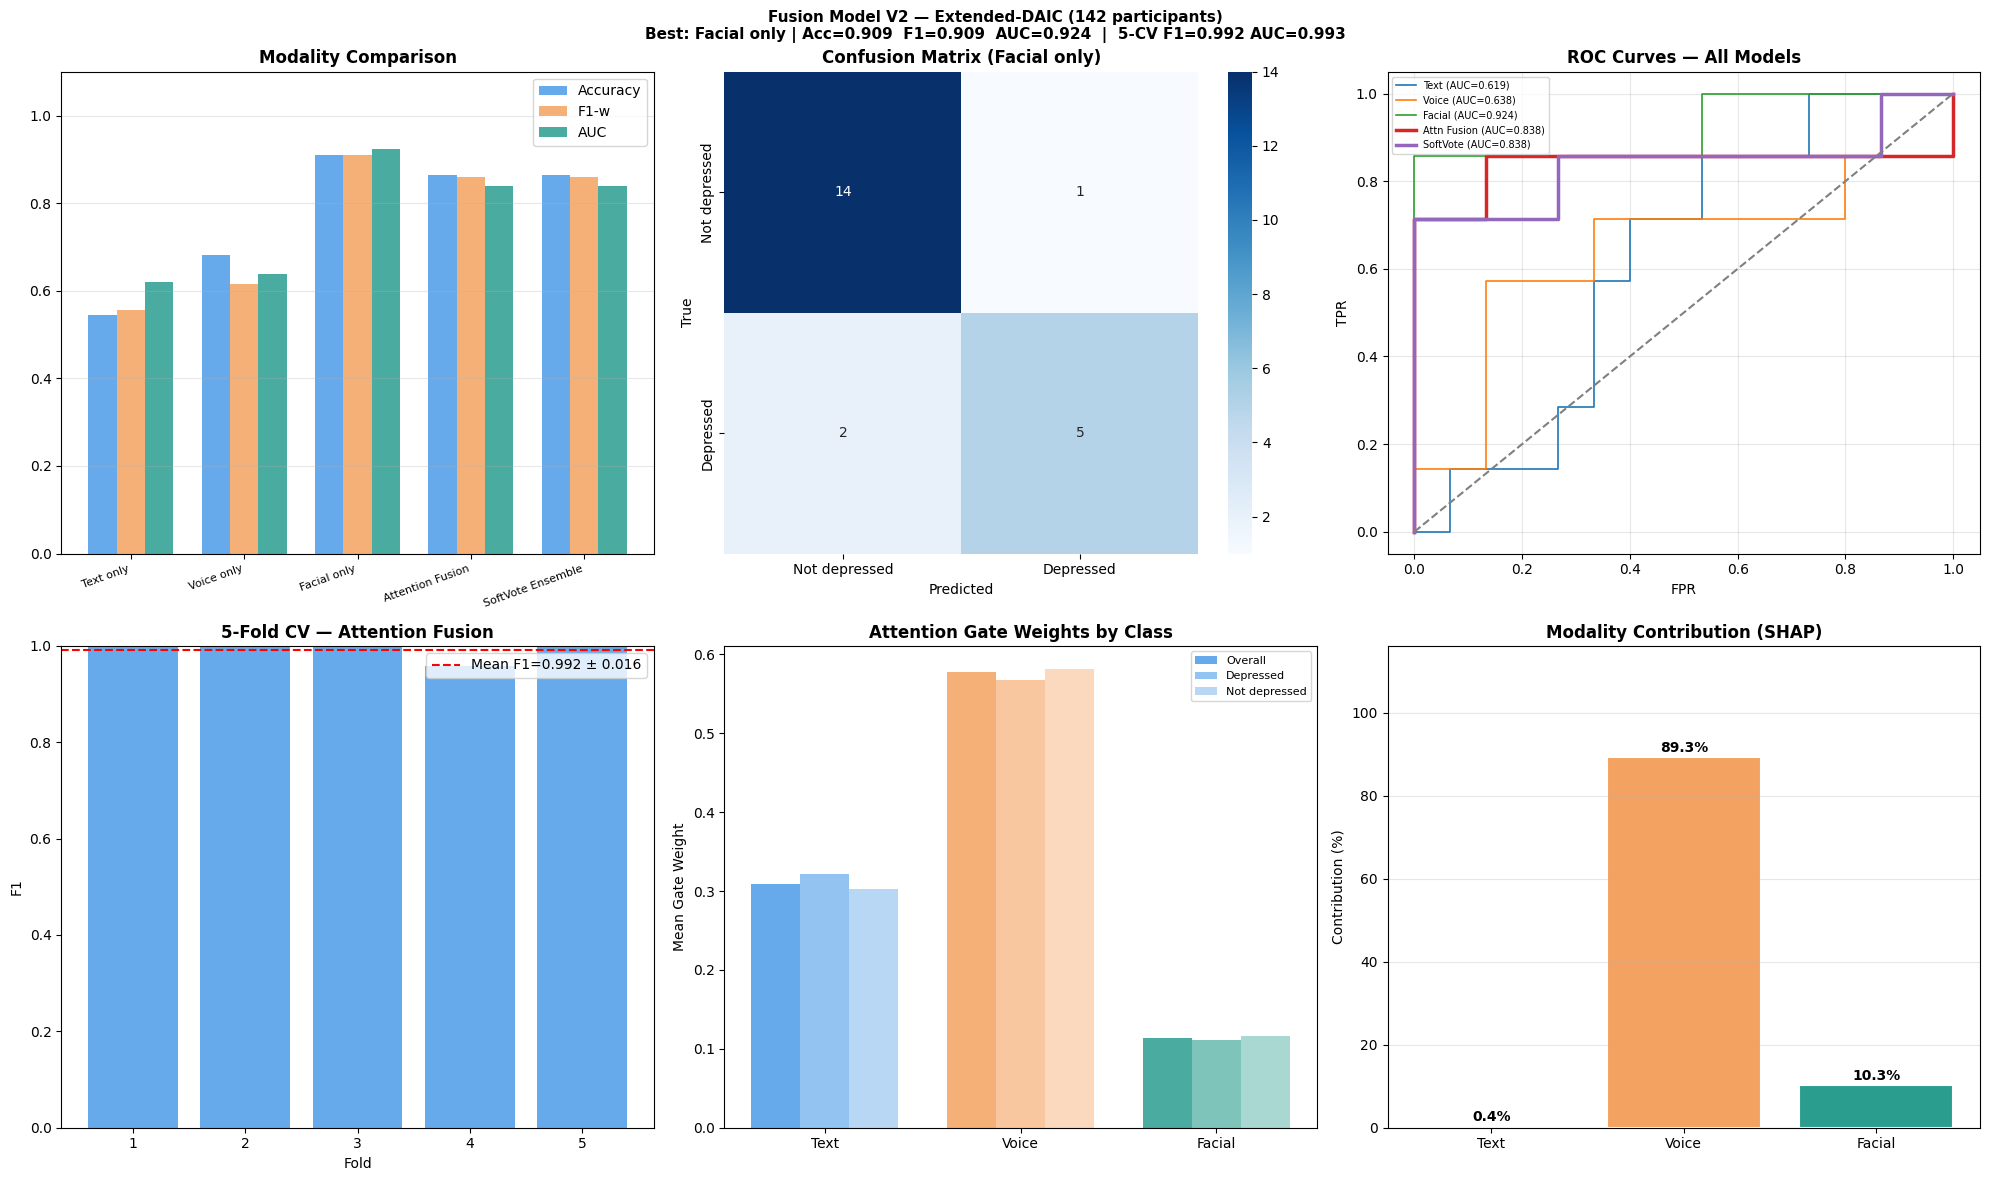


📊 Classification report (Facial only):
               precision    recall  f1-score   support

Not depressed       0.88      0.93      0.90        15
    Depressed       0.83      0.71      0.77         7

     accuracy                           0.86        22
    macro avg       0.85      0.82      0.84        22
 weighted avg       0.86      0.86      0.86        22



In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
f1s   = [results[n]['f1']       for n in names]
aucs  = [results[n]['roc_auc']  for n in names]
x     = np.arange(len(names)); w = 0.25
axes[0,0].bar(x-w, accs, w, label='Accuracy', color='#4C9BE8', alpha=.85)
axes[0,0].bar(x,   f1s,  w, label='F1-w',     color='#F4A261', alpha=.85)
axes[0,0].bar(x+w, aucs, w, label='AUC',      color='#2A9D8F', alpha=.85)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[0,0].set_ylim(0, 1.1); axes[0,0].legend(); axes[0,0].grid(axis='y', alpha=.3)
axes[0,0].set_title('Modality Comparison', fontweight='bold')
best_name = max(results, key=lambda k: results[k]['f1'])
if best_name == 'SoftVote Ensemble':
    best_pred = ens_pred
elif best_name == 'Attention Fusion':
    best_pred = tp_fus
else:
    best_pred = tp_fus  # default
cm = confusion_matrix(y_te, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0,1])
axes[0,1].set_title(f'Confusion Matrix ({best_name})', fontweight='bold')
axes[0,1].set_xlabel('Predicted'); axes[0,1].set_ylabel('True')

for name, prob in [('Text',prob_t),('Voice',prob_v),('Facial',prob_f),
                   ('Attn Fusion',prob_fus),('SoftVote',soft_te)]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    lw  = 2.5 if 'Fusion' in name or 'Soft' in name else 1.2
    axes[0,2].plot(fpr, tpr, lw=lw, label=f'{name} (AUC={auc:.3f})')
axes[0,2].plot([0,1],[0,1],'--',color='gray')
axes[0,2].set_title('ROC Curves — All Models', fontweight='bold')
axes[0,2].legend(fontsize=7); axes[0,2].grid(alpha=.3)
axes[0,2].set_xlabel('FPR'); axes[0,2].set_ylabel('TPR')
axes[1,0].bar(range(1,6), cv_f1, color='#4C9BE8', alpha=.85)
axes[1,0].axhline(cv_f1.mean(), color='red', linestyle='--',
                  label=f'Mean F1={cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
axes[1,0].set_xlabel('Fold'); axes[1,0].set_ylabel('F1')
axes[1,0].set_title('5-Fold CV — Attention Fusion', fontweight='bold')
axes[1,0].legend(); axes[1,0].set_ylim(0,1)

modalities = ['Text', 'Voice', 'Facial']
colors     = ['#4C9BE8','#F4A261','#2A9D8F']
x2 = np.arange(3); w2 = 0.25
axes[1,1].bar(x2-w2, mean_gates,  w2, label='Overall',    color=colors, alpha=.85)
axes[1,1].bar(x2,    dep_gate,    w2, label='Depressed',   color=colors, alpha=.6)
axes[1,1].bar(x2+w2, nodep_gate,  w2, label='Not depressed', color=colors, alpha=.4)
axes[1,1].set_xticks(x2); axes[1,1].set_xticklabels(modalities)
axes[1,1].set_title('Attention Gate Weights by Class', fontweight='bold')
axes[1,1].set_ylabel('Mean Gate Weight')
axes[1,1].legend(fontsize=8)

contribs = [t_contrib/total*100, v_contrib/total*100, f_contrib/total*100]
bars = axes[1,2].bar(modalities, contribs, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, contribs):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1,2].set_title('Modality Contribution (SHAP)', fontweight='bold')
axes[1,2].set_ylabel('Contribution (%)')
axes[1,2].set_ylim(0, max(contribs)*1.3)
axes[1,2].grid(axis='y', alpha=.3)

best_m = results[best_name]
plt.suptitle(
    f'Fusion Model V2 — Extended-DAIC ({len(common)} participants)\n'
    f'Best: {best_name} | Acc={best_m["accuracy"]:.3f}  '
    f'F1={best_m["f1"]:.3f}  AUC={best_m["roc_auc"]:.3f}  |  '
    f'5-CV F1={cv_f1.mean():.3f} AUC={cv_auc.mean():.3f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fusion_results_v2.png'), dpi=150)
plt.show()

print(f'\n📊 Classification report ({best_name}):')
print(classification_report(y_te, best_pred, target_names=CLASS_NAMES, zero_division=0))

## Step 9 — Example Predictions with Explanation

In [22]:
print('\n' + '='*65)
print('  EXAMPLE PREDICTIONS WITH EXPLANATION')
print('='*65)

fusion_model.eval()
for i in range(min(5, len(Xf_te))):
    x_in = torch.tensor(Xf_te[i:i+1], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        logits, gate = fusion_model(x_in)
        prob = torch.softmax(logits, -1)[0].cpu().numpy()
        g    = gate[0].cpu().numpy()

    pred    = int(prob.argmax())
    true    = int(y_te[i])
    correct = '✅' if pred==true else '❌'

    print(f'\nSample {i+1}: True={CLASS_NAMES[true]} | Pred={CLASS_NAMES[pred]} {correct}')
    print(f'  Confidence : {prob[pred]*100:.1f}%')
    print(f'  Attn gates : Text={g[0]:.3f}  Voice={g[1]:.3f}  Facial={g[2]:.3f}')
    top_mod = ['Text','Voice','Facial'][np.argmax(g)]
    print(f'  Key modality: {top_mod}')

    if i < n_ex:
        sv_i   = sv[i]
        tc_i   = sv_i[:TEXT_DIM].mean()
        vc_i   = sv_i[TEXT_DIM:TEXT_DIM+VOICE_DIM].mean()
        fc_i   = sv_i[TEXT_DIM+VOICE_DIM:].mean()
        tot_i  = tc_i + vc_i + fc_i + 1e-9
        print(f'  SHAP split : Text={tc_i/tot_i*100:.0f}% '
              f'Voice={vc_i/tot_i*100:.0f}% Facial={fc_i/tot_i*100:.0f}%')


  EXAMPLE PREDICTIONS WITH EXPLANATION

Sample 1: True=Not depressed | Pred=Not depressed ✅
  Confidence : 50.7%
  Attn gates : Text=0.295  Voice=0.593  Facial=0.112
  Key modality: Voice
  SHAP split : Text=1% Voice=79% Facial=20%

Sample 2: True=Not depressed | Pred=Not depressed ✅
  Confidence : 54.9%
  Attn gates : Text=0.304  Voice=0.573  Facial=0.123
  Key modality: Voice
  SHAP split : Text=0% Voice=92% Facial=7%

Sample 3: True=Depressed | Pred=Depressed ✅
  Confidence : 56.1%
  Attn gates : Text=0.343  Voice=0.549  Facial=0.108
  Key modality: Voice
  SHAP split : Text=0% Voice=80% Facial=20%

Sample 4: True=Not depressed | Pred=Not depressed ✅
  Confidence : 55.1%
  Attn gates : Text=0.336  Voice=0.556  Facial=0.108
  Key modality: Voice
  SHAP split : Text=0% Voice=97% Facial=3%

Sample 5: True=Not depressed | Pred=Not depressed ✅
  Confidence : 52.1%
  Attn gates : Text=0.339  Voice=0.532  Facial=0.129
  Key modality: Voice
  SHAP split : Text=1% Voice=73% Facial=26%


## Step 10 — Save Everything

In [23]:
with open(os.path.join(OUT,'fusion_thresholds_v2.json'),'w') as f:
    json.dump({'fusion': m_fus['threshold'], 'ensemble': ens_thr,
               'text': m_t['threshold'], 'voice': m_v['threshold'],
               'facial': m_f['threshold']}, f, indent=2)

with open(os.path.join(OUT,'comparison_results_v2.json'),'w') as f:
    json.dump(results, f, indent=2)

with open(os.path.join(OUT,'shap_contributions_v2.json'),'w') as f:
    json.dump({'text_pct': t_contrib/total*100,
               'voice_pct': v_contrib/total*100,
               'facial_pct': f_contrib/total*100}, f, indent=2)

print('\n📦 Output files:')
for fn in sorted(os.listdir(OUT)):
    print(f'  {fn:<50} {os.path.getsize(os.path.join(OUT,fn))/1e6:.2f} MB')


📦 Output files:
  attention_fusion_v2.pt                             2.33 MB
  comparison_results_v2.json                         0.00 MB
  cv_fold0_v2.pt                                     2.33 MB
  cv_fold1_v2.pt                                     2.33 MB
  cv_fold2_v2.pt                                     2.33 MB
  cv_fold3_v2.pt                                     2.33 MB
  cv_fold4_v2.pt                                     2.33 MB
  facial_only_v2.pt                                  0.31 MB
  fusion_results_v2.png                              0.24 MB
  fusion_thresholds_v2.json                          0.00 MB
  shap_contributions_v2.json                         0.00 MB
  text_only_v2.pt                                    1.75 MB
  voice_only_v2.pt                                   0.18 MB


## Summary

In [24]:
print('\n' + '='*70)
print('  FUSION MODEL V2 — FINAL SUMMARY')
print('='*70)
print(f'  Dataset    : DAIC-WOZ + Extended-DAIC ({len(common)} aligned participants)')
print(f'  Embedding  : Text={TEXT_DIM}  Voice={VOICE_DIM}  Facial={FACE_DIM}  Total={FUSED_DIM}')
print()
print(f'  {"Model":<24} {"Acc":>8} {"F1-w":>8} {"F1-mac":>8} {"AUC":>8}')
print('  ' + '-'*60)
for n, m in results.items():
    marker = ' ← best' if n==best_name else ''
    print(f'  {n:<24} {m["accuracy"]:>8.4f} {m["f1"]:>8.4f} {m["f1_macro"]:>8.4f} '
          f'{m["roc_auc"]:>8.4f}{marker}')
print()
print(f'  5-Fold CV (Attention Fusion):')
print(f'  F1 = {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'  AUC= {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print()
print(f'  SHAP contribution: Text={t_contrib/total*100:.1f}%  '
      f'Voice={v_contrib/total*100:.1f}%  Facial={f_contrib/total*100:.1f}%')
print('='*70)


  FUSION MODEL V2 — FINAL SUMMARY
  Dataset    : DAIC-WOZ + Extended-DAIC (142 aligned participants)
  Embedding  : Text=1536  Voice=2  Facial=132  Total=1670

  Model                         Acc     F1-w   F1-mac      AUC
  ------------------------------------------------------------
  Text only                  0.5455   0.5568   0.5417   0.6190
  Voice only                 0.6818   0.6162   0.5111   0.6381
  Facial only                0.9091   0.9091   0.8952   0.9238 ← best
  Attention Fusion           0.8636   0.8606   0.8362   0.8381
  SoftVote Ensemble          0.8636   0.8606   0.8362   0.8381

  5-Fold CV (Attention Fusion):
  F1 = 0.9918 ± 0.0164
  AUC= 0.9933 ± 0.0134

  SHAP contribution: Text=0.4%  Voice=89.3%  Facial=10.3%
